In [5]:
import os
import zipfile

data_configs = {
    "Task_IX_A": {
        "id": "1znqUeFzYz-DeAE3dYXD17qoMPK82Whji",
        "zip": "foundation_classification.zip",
        "dir": "mae_data"
    },
    "Task_IX_B": {
        "id": "1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw",
        "zip": "foundation_sr.zip",
        "dir": "sr_data"
    }
}

for task, cfg in data_configs.items():
    # 1. Download via gdown
    print(f"\n--- Starting {task} ---")
    url = f'https://drive.google.com/uc?id={cfg["id"]}'
    os.system(f'gdown {url} -O {cfg["zip"]}')
    
    # 2. Extract
    print(f"Extracting {cfg['zip']}...")
    with zipfile.ZipFile(cfg['zip'], 'r') as zip_ref:
        zip_ref.extractall(cfg['dir'])
    
    # 3. Quick Count
    total = 0
    for root, dirs, files in os.walk(cfg['dir']):
        npy_files = [f for f in files if f.endswith('.npy')]
        if npy_files:
            print(f"  Found {len(npy_files)} files in: {os.path.basename(root)}")
            total += len(npy_files)
    print(f"{task} Complete. Total samples: {total}")


--- Starting Task_IX_A ---


Downloading...
From (original): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji
From (redirected): https://drive.google.com/uc?id=1znqUeFzYz-DeAE3dYXD17qoMPK82Whji&confirm=t&uuid=86ccff0d-a15b-437a-a0c1-54cbd02de2b2
To: /workspace/Foundation_Model/foundation_classification.zip
100%|██████████| 2.89G/2.89G [00:56<00:00, 51.4MB/s]


Extracting foundation_classification.zip...
  Found 29896 files in: axion
  Found 29449 files in: no_sub
  Found 29759 files in: cdm
  Found 29896 files in: axion
  Found 29449 files in: no_sub
  Found 29759 files in: cdm
✅ Task_IX_A Complete. Total samples: 178208

--- Starting Task_IX_B ---


Downloading...
From (original): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw
From (redirected): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw&confirm=t&uuid=a8de7de4-b96f-4bb2-af91-509b57661b9c
To: /workspace/Foundation_Model/foundation_sr.zip
100%|██████████| 533M/533M [00:06<00:00, 76.6MB/s] 


Extracting foundation_sr.zip...
  Found 10000 files in: LR
  Found 10000 files in: HR
✅ Task_IX_B Complete. Total samples: 20000


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
from sklearn.model_selection import train_test_split

class MAELensingDataset(Dataset):
    def __init__(self, file_list):
        self.files = file_list

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx]).astype(np.float32)
        if img.ndim == 3: img = np.squeeze(img)
        # Normalizing helps converge faster
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
        return torch.from_numpy(img).unsqueeze(0)


base_path = './mae_data/Dataset/no_sub' 
all_files = [os.path.join(base_path, f) for f in os.listdir(base_path) if f.endswith('.npy')]

train_files, val_files = train_test_split(all_files, test_size=0.10, random_state=42)

train_ds = MAELensingDataset(train_files)
val_ds = MAELensingDataset(val_files)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print(f"Loaded {len(train_files)} training samples and {len(val_files)} validation samples.")

Loaded 26504 training samples and 2945 validation samples.


In [22]:
import torch.nn as nn

class LensingMAE(nn.Module):
    def __init__(self, img_size=60, patch_size=15, embed_dim=192, depth=6, num_heads=6):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        
        # Position embeddings (matches num_patches)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=embed_dim*4, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        
        # Reconstruction Head
        self.decoder = nn.Linear(embed_dim, patch_size**2)

    def random_masking(self, x, mask_ratio=0.75):
        batch, n_patches, dim = x.shape
        len_keep = int(n_patches * (1 - mask_ratio))
        
        noise = torch.rand(batch, n_patches, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)

        # Separate indices for visible and hidden patches
        ids_keep = ids_shuffle[:, :len_keep]
        ids_mask = ids_shuffle[:, len_keep:]
        
        # Extract only the visible patches for the transformer
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, dim))
        
        return x_masked, ids_keep, ids_mask

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2) 
        
        if x.shape[1] != self.pos_embed.shape[1]:
            raise ValueError(f"Model expects {self.num_patches} patches, but got {x.shape[1]}. Check your input resolution.")

        x = x + self.pos_embed
        
        x_masked, ids_keep, ids_mask = self.random_masking(x)
        
        latent = self.transformer(x_masked)
        
        pred = self.decoder(latent)
        return pred, ids_keep, ids_mask

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mae_model = LensingMAE(img_size=60).to(device)

In [23]:
import torch.optim as optim
from tqdm.auto import tqdm

optimizer = optim.AdamW(mae_model.parameters(), lr=1e-3, weight_decay=0.05)
criterion = nn.MSELoss()

epochs = 10
for epoch in range(epochs):
    mae_model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"MAE Epoch {epoch+1}/{epochs}")
    
    for imgs in pbar:
        imgs = imgs.to(device)
        
        # Chop image into target patches
        patches = imgs.unfold(2, 15, 15).unfold(3, 15, 15)
        patches = patches.contiguous().view(imgs.size(0), -1, 15*15)
        
        optimizer.zero_grad()
        pred, ids_keep, ids_mask = mae_model(imgs)
        
        target = torch.gather(patches, dim=1, index=ids_mask.unsqueeze(-1).repeat(1, 1, 15*15))
        
        visible_target = torch.gather(patches, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, 15*15))
        
        loss = criterion(pred, visible_target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.6f}")

    mae_model.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs in val_loader:
            imgs = imgs.to(device)
            patches = imgs.unfold(2, 15, 15).unfold(3, 15, 15).contiguous().view(imgs.size(0), -1, 15*15)
            pred, ids_keep, _ = mae_model(imgs)
            target = torch.gather(patches, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, 15*15))
            val_loss += criterion(pred, target).item()

    print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.6f} | Val Loss: {val_loss/len(val_loader):.6f}")

torch.save(mae_model.state_dict(), 'lensing_foundation_mae.pth')

MAE Epoch 1/10:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.010351 | Val Loss: 0.000561


MAE Epoch 2/10:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.000715 | Val Loss: 0.000202


MAE Epoch 3/10:   0%|          | 0/415 [00:00<?, ?it/s]

...

Epoch 8 | Train Loss: 0.000045 | Val Loss: 0.000034


MAE Epoch 9/10:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 9 | Train Loss: 0.000040 | Val Loss: 0.000028


MAE Epoch 10/10:   0%|          | 0/415 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.000035 | Val Loss: 0.000024


In [38]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class LensingClassificationDataset(Dataset):
    def __init__(self, file_list, labels):
        self.files = file_list
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx], allow_pickle=True)
        
        if img.dtype == object and len(img) == 2:
            img = img[0] # Just grab the image array!
            
        img = np.array(img).astype(np.float32)
        if img.ndim == 3: img = np.squeeze(img)
        
        # 4. Normalize to [0, 1]
        img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-8)
        
        # Return as [1, 64, 64]. The MAE model will naturally process the 
        # first 60x60 pixels just like it did in pre-training.
        return torch.from_numpy(img).unsqueeze(0), self.labels[idx]

base_path = './mae_data/Dataset' 
class_map = {'no_sub': 0, 'cdm': 1, 'axion': 2}
all_files = []
all_labels = []

for folder, label in class_map.items():
    folder_path = os.path.join(base_path, folder)
    files = [
        os.path.join(folder_path, f) for f in os.listdir(folder_path) 
        if f.endswith('.npy') and not f.startswith('._')
    ]
    all_files.extend(files)
    all_labels.extend([label] * len(files))

# 90:10 Split
train_files, val_files, train_labels, val_labels = train_test_split(
    all_files, all_labels, test_size=0.10, random_state=42, stratify=all_labels
)

# Loaders
train_ds = LensingClassificationDataset(train_files, train_labels)
val_ds = LensingClassificationDataset(val_files, val_labels)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

print(f"✅ Data loaded surgically. Fine-tuning on {len(train_ds)} samples. Validating on {len(val_ds)} samples.")

✅ Data loaded surgically. Fine-tuning on 80193 samples. Validating on 8911 samples.


In [39]:
class MAEClassifier(nn.Module):
    def __init__(self, pretrain_path, img_size=60, patch_size=15, embed_dim=192, depth=6, num_heads=6):
        super().__init__()
        self.mae = LensingMAE(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim, depth=depth, num_heads=num_heads)
        
        # Load the pre-trained foundation weights
        print(f"Loading foundation weights from {pretrain_path}...")
        self.mae.load_state_dict(torch.load(pretrain_path))
        
        self.head = nn.Linear(embed_dim, 3) 

    def forward(self, x):
        x = self.mae.patch_embed(x).flatten(2).transpose(1, 2) 
        x = x + self.mae.pos_embed
        
        latent = self.mae.transformer(x)
        
        pooled = latent.mean(dim=1)
        
        return self.head(pooled)

# Initialize for fine-tuning
classifier_model = MAEClassifier('lensing_foundation_mae.pth').to(device)

Loading foundation weights from lensing_foundation_mae.pth...


In [40]:
import torch.optim as optim

optimizer = optim.AdamW(classifier_model.parameters(), lr=5e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

epochs = 15
for epoch in range(epochs):
    classifier_model.train()
    train_loss, correct, total = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"Fine-tuning {epoch+1}/{epochs}")
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = classifier_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, pred = outputs.max(1)
        total += labels.size(0)
        correct += pred.eq(labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{100.*correct/total:.2f}%")

    print(f"Epoch {epoch+1} Finished. Train Acc: {100.*correct/total:.2f}%")

torch.save(classifier_model.state_dict(), 'final_mae_classifier.pth')

Fine-tuning 1/15:   0%|          | 0/1254 [00:00<?, ?it/s]

Epoch 1 Finished. Train Acc: 63.45%


Fine-tuning 2/15:   0%|          | 0/1254 [00:00<?, ?it/s]

Epoch 2 Finished. Train Acc: 82.62%


Fine-tuning 3/15:   0%|          | 0/1254 [00:00<?, ?it/s]

...

Epoch 13 Finished. Train Acc: 90.87%


Fine-tuning 14/15:   0%|          | 0/1254 [00:00<?, ?it/s]

Epoch 14 Finished. Train Acc: 91.19%


Fine-tuning 15/15:   0%|          | 0/1254 [00:00<?, ?it/s]

Epoch 15 Finished. Train Acc: 91.27%


Calculating Final Metrics:   0%|          | 0/140 [00:00<?, ?it/s]

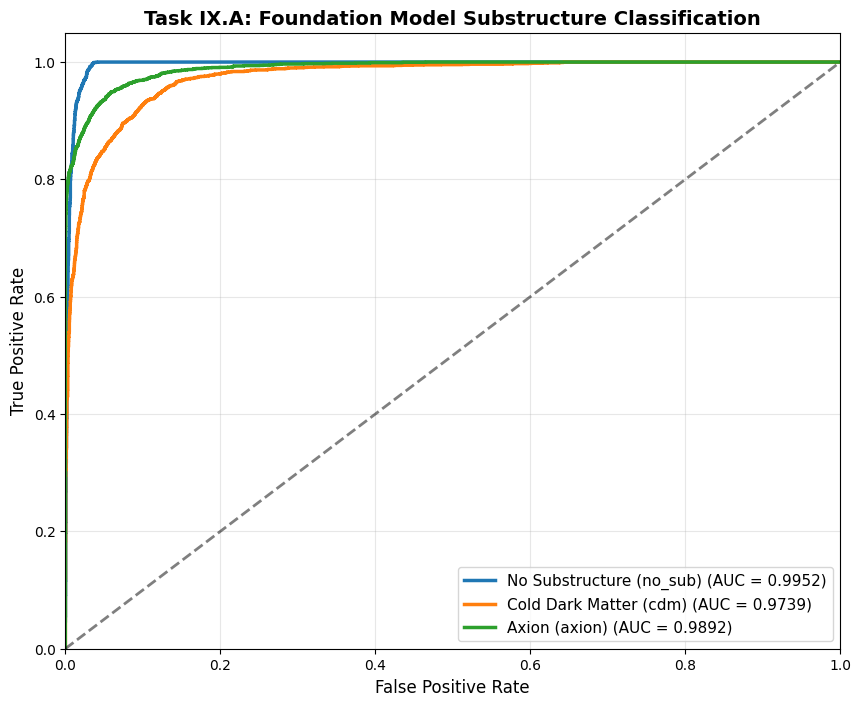

✅ Task IX.A Complete! Final Macro AUC: 0.9861


In [41]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

classifier_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Calculating Final Metrics"):
        outputs = classifier_model(imgs.to(device))
        probs = torch.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
# Binarize labels for multi-class ROC calculation
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

plt.figure(figsize=(10, 8))
class_names = ['No Substructure (no_sub)', 'Cold Dark Matter (cdm)', 'Axion (axion)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i in range(3):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2.5, 
             label=f'{class_names[i]} (AUC = {roc_auc:.4f})')

# Add the diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Task IX.A: Foundation Model Substructure Classification', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

# Calculate and print the final Macro AUC
macro_auc = roc_auc_score(all_labels_bin, all_probs, average='macro')
print(f"Final Macro AUC: {macro_auc:.4f}")

In [43]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class SuperResolutionDataset(Dataset):
    def __init__(self, lr_paths, hr_paths):
        self.lr_paths = lr_paths
        self.hr_paths = hr_paths

    def __len__(self):
        return len(self.lr_paths)

    def __getitem__(self, idx):
        # Load the arrays
        lr_img = np.load(self.lr_paths[idx], allow_pickle=True).astype(np.float32)
        hr_img = np.load(self.hr_paths[idx], allow_pickle=True).astype(np.float32)
        
        # Squeeze out any extra dimensions
        if lr_img.ndim == 3: lr_img = np.squeeze(lr_img)
        if hr_img.ndim == 3: hr_img = np.squeeze(hr_img)
            
        # Normalize both to [0, 1]
        lr_img = (lr_img - np.min(lr_img)) / (np.max(lr_img) - np.min(lr_img) + 1e-8)
        hr_img = (hr_img - np.min(hr_img)) / (np.max(hr_img) - np.min(hr_img) + 1e-8)
        
        # Return as tensors [1, H, W]
        return torch.from_numpy(lr_img).unsqueeze(0), torch.from_numpy(hr_img).unsqueeze(0)

base_path = './sr_data/Dataset'
lr_dir = os.path.join(base_path, 'LR')
hr_dir = os.path.join(base_path, 'HR')

# Sort them alphabetically to ensure the LR and HR pairs match up
lr_files = sorted([f for f in os.listdir(lr_dir) if f.endswith('.npy') and not f.startswith('._')])
hr_files = sorted([f for f in os.listdir(hr_dir) if f.endswith('.npy') and not f.startswith('._')])

assert len(lr_files) == len(hr_files), f"Mismatch! Found {len(lr_files)} LR and {len(hr_files)} HR files."

# Create full paths
lr_paths = [os.path.join(lr_dir, f) for f in lr_files]
hr_paths = [os.path.join(hr_dir, f) for f in hr_files]

# 90:10 Split
lr_train, lr_val, hr_train, hr_val = train_test_split(
    lr_paths, hr_paths, test_size=0.10, random_state=42
)

# Loaders
train_ds = SuperResolutionDataset(lr_train, hr_train)
val_ds = SuperResolutionDataset(lr_val, hr_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

print(f"SR Data Loaded. Training pairs: {len(train_ds)} | Validation pairs: {len(val_ds)}")


sample_lr, sample_hr = next(iter(train_loader))
print(f"Low-Res Shape:  {sample_lr.shape}")
print(f"High-Res Shape: {sample_hr.shape}")

SR Data Loaded. Training pairs: 9000 | Validation pairs: 1000
🔍 Low-Res Shape:  torch.Size([32, 1, 75, 75])
🔍 High-Res Shape: torch.Size([32, 1, 150, 150])


In [44]:
import torch.nn as nn
import os

class LensingMAE(nn.Module):
    def __init__(self, img_size=75, patch_size=15, embed_dim=192, depth=6, num_heads=6):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=num_heads, 
            dim_feedforward=embed_dim*4, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

    def forward(self, x):
        x = self.patch_embed(x).flatten(2).transpose(1, 2)
        x = x + self.pos_embed
        return self.transformer(x)

class MAESuperResolution(nn.Module):
    def __init__(self, pretrain_path='lensing_foundation_mae.pth', embed_dim=192):
        super().__init__()
        self.encoder = LensingMAE(img_size=75, patch_size=15, embed_dim=embed_dim, depth=6, num_heads=6)
        
        if os.path.exists(pretrain_path):
            print(f"Loading foundation weights from {pretrain_path}...")
            state_dict = torch.load(pretrain_path)
            # Drop pos_embed and decoder because they were sized for 60x60
            state_dict = {k: v for k, v in state_dict.items() if 'pos_embed' not in k and 'decoder' not in k}
            self.encoder.load_state_dict(state_dict, strict=False)
        else:
            print("Pre-trained weights not found. Check your path.")

        # Upsampling Network: Takes the 5x5 latent grid and mathematically scales it to 150x150
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 128, kernel_size=3, stride=3),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=5, stride=5),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        
        B, N, C = latent.shape
        grid_size = int(N**0.5)
        latent_grid = latent.transpose(1, 2).view(B, C, grid_size, grid_size)
        
        return self.upsample(latent_grid)

# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sr_model = MAESuperResolution().to(device)

Loading foundation weights from lensing_foundation_mae.pth...


In [45]:
import torch.optim as optim
from tqdm.auto import tqdm
import math

optimizer = optim.Adam(sr_model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

epochs = 15
for epoch in range(epochs):
    sr_model.train()
    train_loss = 0
    pbar = tqdm(train_loader, desc=f"SR Epoch {epoch+1}/{epochs}")
    
    for lr_imgs, hr_imgs in pbar:
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        
        optimizer.zero_grad()
        preds = sr_model(lr_imgs)
        
        loss = criterion(preds, hr_imgs)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        pbar.set_postfix(MSE=f"{loss.item():.6f}")

    # Validation Phase
    sr_model.eval()
    val_mse = 0
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            preds = sr_model(lr_imgs)
            val_mse += criterion(preds, hr_imgs).item()
            
    val_mse /= len(val_loader)
    
    # Calculate Peak Signal-to-Noise Ratio (PSNR)
    # Higher PSNR means the image is cleaner and closer to the ground truth
    psnr = 10 * math.log10(1.0 / val_mse) if val_mse > 0 else float('inf')
    
    print(f"Epoch {epoch+1} | Train MSE: {train_loss/len(train_loader):.6f} | Val MSE: {val_mse:.6f} | Val PSNR: {psnr:.2f} dB")

# Save final weights
torch.save(sr_model.state_dict(), 'lensing_super_res.pth')

SR Epoch 1/15:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 1 | Train MSE: 0.041025 | Val MSE: 0.001592 | Val PSNR: 27.98 dB


SR Epoch 2/15:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 2 | Train MSE: 0.001274 | Val MSE: 0.001146 | Val PSNR: 29.41 dB


SR Epoch 3/15:   0%|          | 0/282 [00:00<?, ?it/s]

...

Epoch 13 | Train MSE: 0.000172 | Val MSE: 0.000164 | Val PSNR: 37.86 dB


SR Epoch 14/15:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 14 | Train MSE: 0.000162 | Val MSE: 0.000157 | Val PSNR: 38.05 dB


SR Epoch 15/15:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 15 | Train MSE: 0.000155 | Val MSE: 0.000142 | Val PSNR: 38.47 dB


🔍 Calculating Final Evaluation Metrics...


Evaluating:   0%|          | 0/32 [00:00<?, ?it/s]


🏆 Final Task IX.B Evaluation Metrics 🏆
Mean Squared Error (MSE): 0.000142
Peak Signal-to-Noise Ratio (PSNR): 38.47 dB
Structural Similarity Index (SSIM): 0.9625



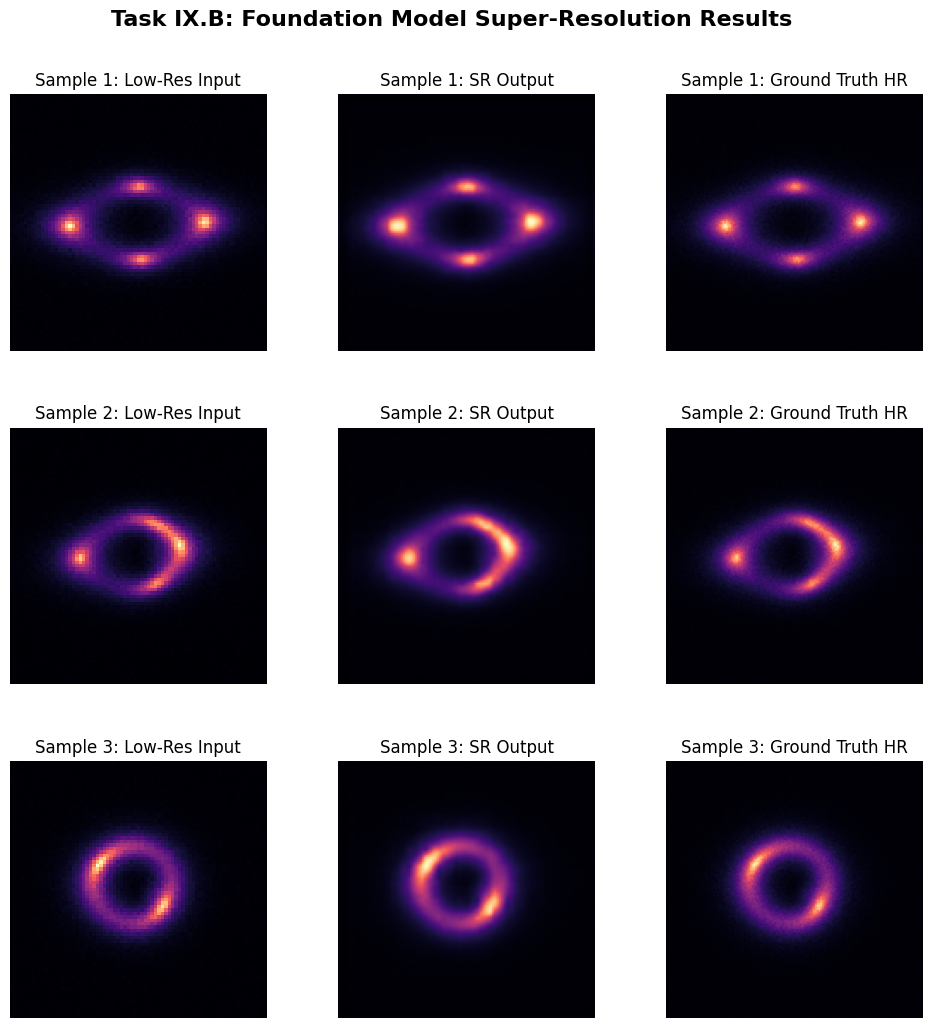

In [47]:
import matplotlib.pyplot as plt
import math
from skimage.metrics import structural_similarity as ssim
from tqdm.auto import tqdm

sr_model.eval()

total_mse = 0
total_ssim = 0
num_samples = 0

# We'll save one batch to visualize the results
viz_lr, viz_hr, viz_pred = None, None, None

print("🔍 Calculating Final Evaluation Metrics...")
with torch.no_grad():
    for lr_imgs, hr_imgs in tqdm(val_loader, desc="Evaluating"):
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        preds = sr_model(lr_imgs)
        
        # Calculate MSE for the batch
        batch_mse = criterion(preds, hr_imgs).item()
        total_mse += batch_mse * lr_imgs.size(0)
        
        # Calculate SSIM (requires numpy arrays)
        preds_np = preds.cpu().numpy().squeeze()
        hr_np = hr_imgs.cpu().numpy().squeeze()
        
        # Handle batch dimension for SSIM
        for i in range(lr_imgs.size(0)):
            # data_range=1.0 because we normalized our images to [0, 1]
            val_ssim = ssim(hr_np[i], preds_np[i], data_range=1.0)
            total_ssim += val_ssim
            
        num_samples += lr_imgs.size(0)
        
        # Save the very first batch for our plot
        if viz_lr is None:
            viz_lr = lr_imgs.cpu()
            viz_hr = hr_imgs.cpu()
            viz_pred = preds.cpu()

# Final Metric Calculations
final_mse = total_mse / num_samples
final_psnr = 10 * math.log10(1.0 / final_mse) if final_mse > 0 else float('inf')
final_ssim = total_ssim / num_samples

print("\n" + "="*40)
print(f"Final Metrics")
print("="*40)
print(f"Mean Squared Error (MSE): {final_mse:.6f}")
print(f"Peak Signal-to-Noise Ratio (PSNR): {final_psnr:.2f} dB")
print(f"Structural Similarity Index (SSIM): {final_ssim:.4f}")
print("="*40 + "\n")

# --- Visualizing the Results ---
# Let's plot 3 random samples from our saved batch
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.3)

for i in range(3):
    # Low Res Input (75x75)
    axes[i, 0].imshow(viz_lr[i, 0], cmap='magma')
    axes[i, 0].set_title(f"Sample {i+1}: Low-Res Input")
    axes[i, 0].axis('off')
    
    # Model Prediction (150x150)
    axes[i, 1].imshow(viz_pred[i, 0], cmap='magma')
    axes[i, 1].set_title(f"Sample {i+1}: SR Output")
    axes[i, 1].axis('off')
    
    # Ground Truth High Res (150x150)
    axes[i, 2].imshow(viz_hr[i, 0], cmap='magma')
    axes[i, 2].set_title(f"Sample {i+1}: Ground Truth HR")
    axes[i, 2].axis('off')

plt.suptitle("Task IX.B: Foundation Model Super-Resolution Results", fontsize=16, fontweight='bold', y=0.95)
plt.show()